AdaBoost Accuracy: 0.85
Gradient Boosting Accuracy: 0.8333333333333334
XGBoost Accuracy: 0.8


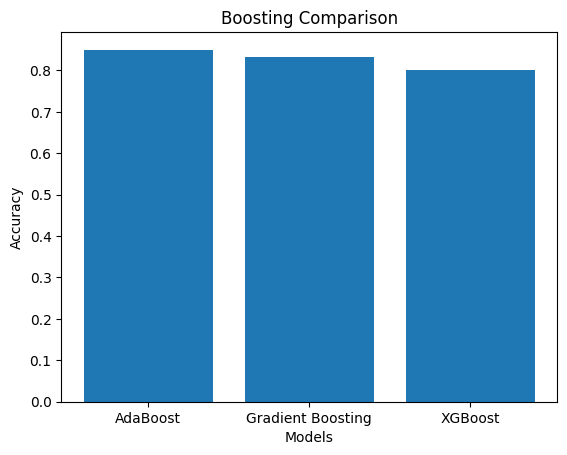

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Load dataset from sklearn
iris = load_iris()

X = iris.data
y = iris.target

# Optional: convert to DataFrame (if needed)
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

# Add Noise
np.random.seed(42)
X = X + np.random.normal(0, 0.5, X.shape)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

# ---------------- AdaBoost ----------------
ada = AdaBoostClassifier(n_estimators=10)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)

# ---------------- Gradient Boosting ----------------
gb = GradientBoostingClassifier(n_estimators=30)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

# ---------------- XGBoost ----------------
xgb = XGBClassifier(n_estimators=30, max_depth=3, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

# Results
print("AdaBoost Accuracy:", acc_ada)
print("Gradient Boosting Accuracy:", acc_gb)
print("XGBoost Accuracy:", acc_xgb)

# Plot
models = ['AdaBoost', 'Gradient Boosting', 'XGBoost']
accuracies = [acc_ada, acc_gb, acc_xgb]

plt.bar(models, accuracies)
plt.title("Boosting Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()